# exercise: makemore part 3 - Activations & Gradients, BatchNorm

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures

%matplotlib inline

In [2]:
words = open("../data/names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
chars = sorted(set("".join(words)))  # <- list of chars from "a" to "z"
stoi = {s: i + 1 for i, s in enumerate(chars)}  # <- dict, {".": 0, "a": 1, "b": 2 ...}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}  # <- dict, {0: ".", 1: "a", 2: "b" ...}

In [4]:
# build the dataset
block_size = 3  # context length: how many characters do we take to predict the next one?


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# MLP revisited
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP
vocab_size = len(itos)

g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5 / 3) / ((n_embd * block_size) ** 0.5)  # * 0.2
# ---------
# we don't need bias because batch norm layer has it's own bias
# b1 = torch.randn(n_hidden, generator=g) * 0.01
# ---------
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    # Linear layer
    hpreact = embcat @ W1  # + b1 # hidden layer pre-activation

    # --------------------BatchNorm layer--------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    # keep running mean and std, not need to calibrate at the end of training
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -------------------------------------------------------------

    # Non-linearity
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2  # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

      0/ 200000: 3.2736
  10000/ 200000: 2.3246
  20000/ 200000: 2.0229
  30000/ 200000: 2.0292
  40000/ 200000: 2.0587
  50000/ 200000: 2.8989
  60000/ 200000: 2.1025
  70000/ 200000: 2.8280
  80000/ 200000: 2.5755
  90000/ 200000: 2.2545
 100000/ 200000: 2.0482
 110000/ 200000: 1.8211
 120000/ 200000: 1.8397
 130000/ 200000: 2.4059
 140000/ 200000: 2.4866
 150000/ 200000: 2.4214
 160000/ 200000: 2.1187
 170000/ 200000: 2.1708
 180000/ 200000: 2.1542
 190000/ 200000: 2.0988


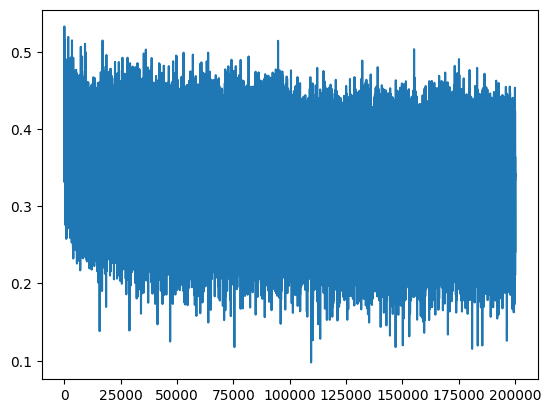

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1  # + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)  # (N, n_hidden)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss("train")
split_loss("val")

train 2.0673089027404785
val 2.105586051940918


In [ ]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch


class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)  # batch mean
            xvar = x.var(0, keepdim=True)  # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 100  # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size, bias=False),
    BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    # layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True

47024


In [12]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break  # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.62%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.47%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.16%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
layer 14 (      Tanh): mean -0.00, std 0.65, saturated: 1.78%


Text(0.5, 1.0, 'activation distribution')

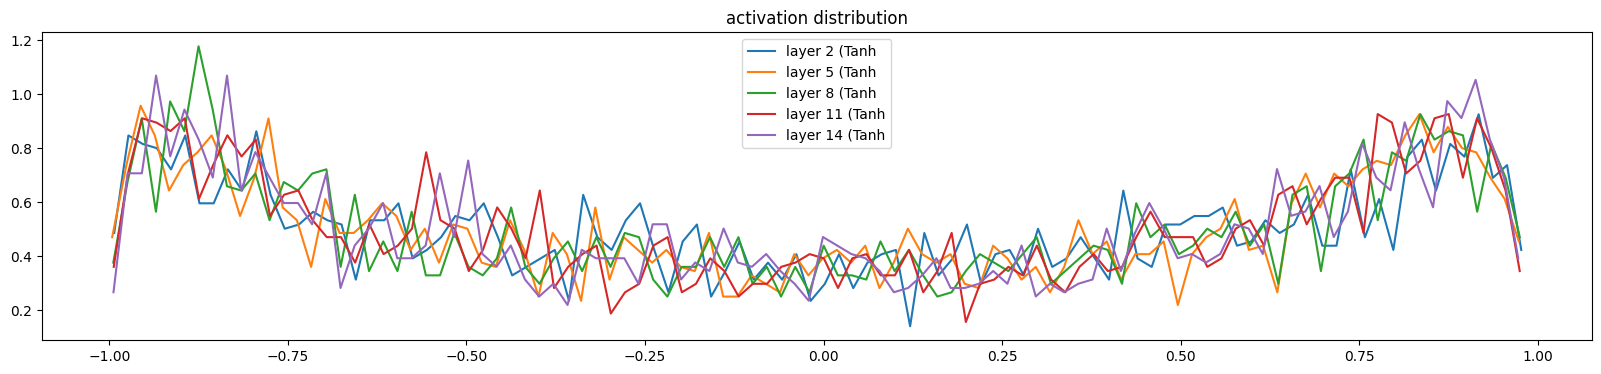

In [20]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print(
            "layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%"
            % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100)
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__}")
plt.legend(legends)
plt.title("activation distribution")

layer 2 (      Tanh): mean -0.000000, std 3.682963e-03
layer 5 (      Tanh): mean -0.000000, std 3.262615e-03
layer 8 (      Tanh): mean -0.000000, std 2.973735e-03
layer 11 (      Tanh): mean -0.000000, std 2.741115e-03
layer 14 (      Tanh): mean +0.000000, std 2.584296e-03


Text(0.5, 1.0, 'gradient distribution')

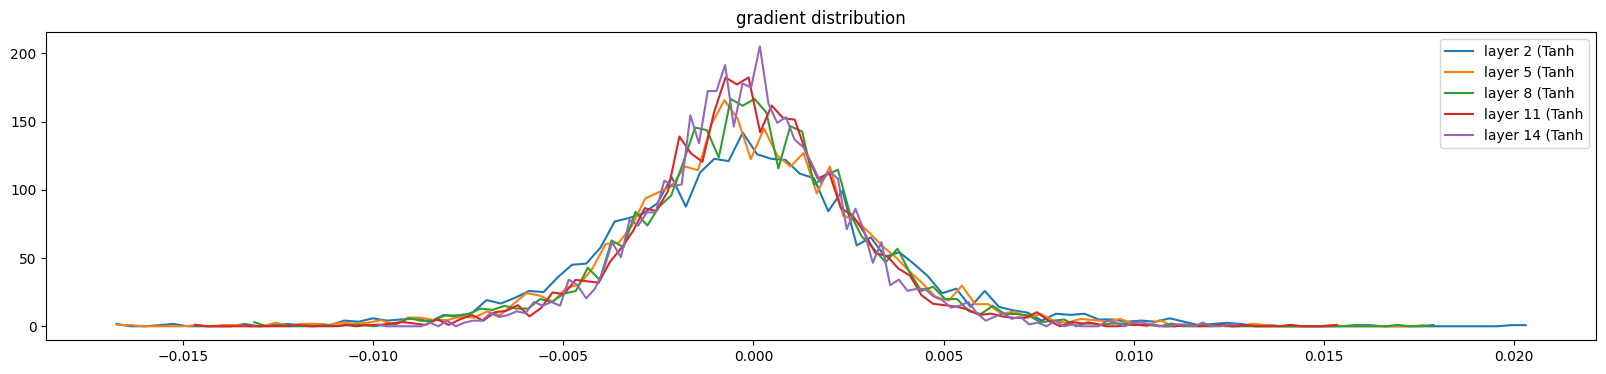

In [19]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s): mean %+f, std %e" % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__}")
plt.legend(legends)
plt.title("gradient distribution")

weight   (27, 10) | mean +0.000000 | std 1.019891e-02 | grad:data ratio 1.018851e-02
weight  (30, 100) | mean +0.000092 | std 8.238452e-03 | grad:data ratio 2.635846e-02
weight (100, 100) | mean +0.000031 | std 7.318132e-03 | grad:data ratio 4.377156e-02
weight (100, 100) | mean -0.000019 | std 6.662033e-03 | grad:data ratio 3.949901e-02
weight (100, 100) | mean -0.000019 | std 5.821522e-03 | grad:data ratio 3.468164e-02
weight (100, 100) | mean +0.000053 | std 5.445304e-03 | grad:data ratio 3.243372e-02
weight  (100, 27) | mean -0.000165 | std 1.046846e-02 | grad:data ratio 6.281275e-02


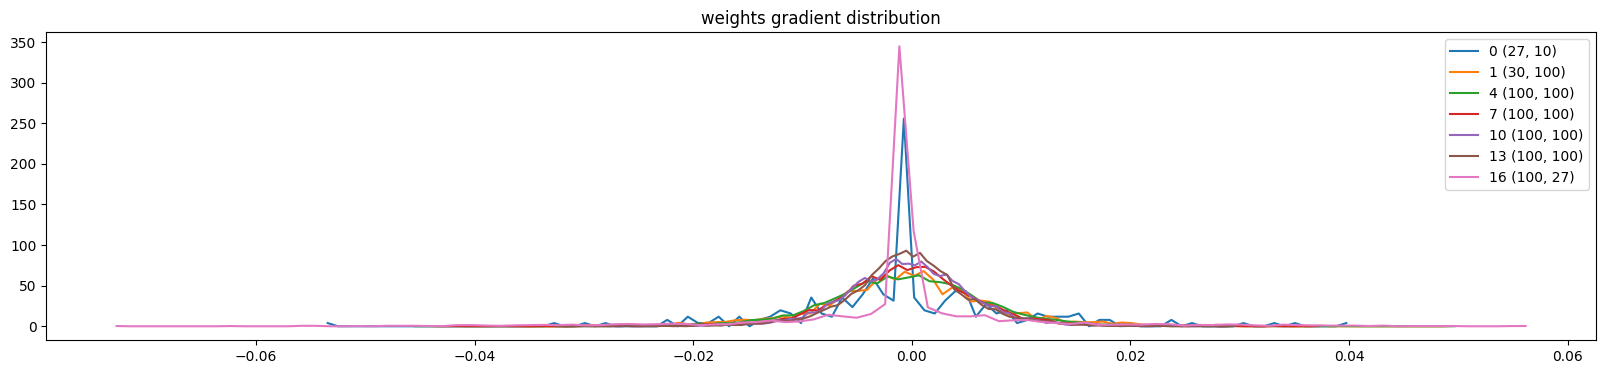

In [21]:
# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print("weight %10s | mean %+f | std %e | grad:data ratio %e" % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"{i} {tuple(p.shape)}")
plt.legend(legends)
plt.title("weights gradient distribution");

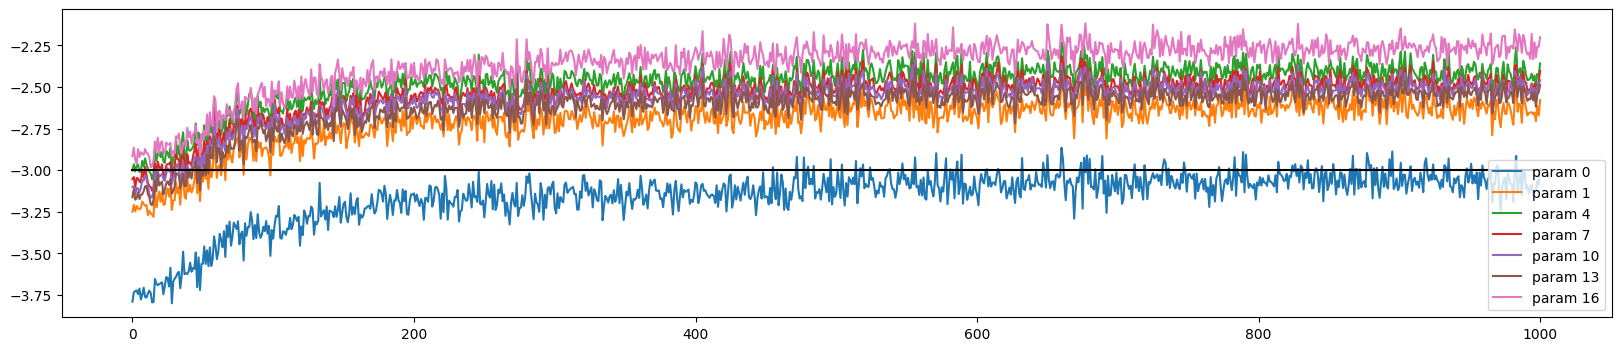

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append("param %d" % i)
plt.plot([0, len(ud)], [-3, -3], "k")  # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## E01:
I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.

In [24]:
# linear layer with all 0 weights
class ZeroLinear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.zeros((fan_in, fan_out))
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [82]:
n_embd = 10
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
L1 = ZeroLinear(n_embd * block_size, n_hidden, bias=True)
tanh = Tanh()
L2 = ZeroLinear(n_hidden, vocab_size, bias=True)
layers = [L1, tanh, L2]

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

6097


In [83]:
# same optimization as last time
max_steps = 100000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

      0/ 100000: 3.2958
  10000/ 100000: 2.7882
  20000/ 100000: 2.7518
  30000/ 100000: 2.8506
  40000/ 100000: 2.8221
  50000/ 100000: 2.8987
  60000/ 100000: 2.6038
  70000/ 100000: 2.6751
  80000/ 100000: 3.0131
  90000/ 100000: 2.7753


In [ ]:
print("L1.weight sum:", L1.weight.sum().item())
print("L1.weight.grad sum:", L1.weight.grad.sum().item())

L1.weight sum: 0.0
L1.weight.grad sum: 0.0


In [91]:
print("L1.bias sum:", L1.bias.sum().item())
print("L1.bias.grad sum:", L1.bias.grad.sum().item())

L1.bias sum: 0.0
L1.bias.grad sum: 0.0


In [90]:
print("tanh.out sum:", tanh.out.sum().item())
print("tanh.out.grad sum:", tanh.out.grad.sum().item())

tanh.out sum: 0.0
tanh.out.grad sum: 0.0


The gradient function of tanh is (1 - t**2) * out.grad, there is something wrong with out.grad, which is the gradient propagated back from L2.

$$\frac{\partial L}{\partial \text{tanh.out}} = \frac{\partial L}{\partial \text{logits}} \cdot \frac{\partial \text{logits}}{\partial \text{tanh.out}}$$

$$\frac{\partial \text{logits}}{\partial \text{tanh.out}} = L2.weight^T$$

because we initialized L2.weight = 0, the gradient can't go through.

In [92]:
print("L2.weight sum:", L2.weight.sum().item())
print("L2.weight.grad sum:", L2.weight.grad.sum().item())

L2.weight sum: 0.0
L2.weight.grad sum: 0.0


In [93]:
print("L2.bias sum:", L2.bias.sum().item())
print("L2.bias.grad sum:", L2.bias.grad.sum().item())

L2.bias sum: 1.4066696166992188e-05
L2.bias.grad sum: 6.891787052154541e-08


Gradient w.r.t. L2.bias:
$$\frac{\partial L}{\partial \text{L2.bias}} = \frac{\partial L}{\partial \text{logits}}$$

Gradient w.r.t. L2.weight:
$$\frac{\partial L}{\partial \text{L2.weight}} = h^T \cdot \frac{\partial L}{\partial \text{logits}}$$

the L2.weight gradient depends on the tanh output, which is always zero.

the L2.bias gradient is fine.

$\text{logits} = h \cdot W_2 + b_2 = 0 \cdot 0 + b_2 = \text{L2.bias}$

L2.bias is a vector of shape (vocab_size,) — the same vector for every input. So the network predicts the same character distribution regardless of context. It's learning the unconditional class prior (which characters are most common in names). That's why the loss plateaus around 2.7 — that's the entropy of the character distribution.

now let's set the L2 properly, but L1 at zero. Does the network learn?

In [99]:
n_embd = 10
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
L1 = ZeroLinear(n_embd * block_size, n_hidden, bias=True)  # <- still zero initialization
tanh = Tanh()
L2 = Linear(n_hidden, vocab_size, bias=True)  # <- random initialization
layers = [L1, tanh, L2]

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 100000
batch_size = 32
lr = 0.1

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")

print("L2.weight sum:", L2.weight.sum().item())
print("L2.weight.grad sum:", L2.weight.grad.sum().item())
print("L2.bias sum:", L2.bias.sum().item())
print("L2.bias.grad sum:", L2.bias.grad.sum().item())
print("tanh.out sum:", tanh.out.sum().item())
print("tanh.out.grad sum:", tanh.out.grad.sum().item())
print("L1.weight sum:", L1.weight.sum().item())
print("L1.weight.grad sum:", L1.weight.grad.sum().item())
print("L1.bias sum:", L1.bias.sum().item())
print("L1.bias.grad sum:", L1.bias.grad.sum().item())

6097
      0/ 100000: 3.2958
  10000/ 100000: 2.2082
  20000/ 100000: 2.4269
  30000/ 100000: 2.2730
  40000/ 100000: 2.3440
  50000/ 100000: 1.8517
  60000/ 100000: 1.9951
  70000/ 100000: 2.0883
  80000/ 100000: 1.9479
  90000/ 100000: 2.1904
L2.weight sum: 5.204076290130615
L2.weight.grad sum: -1.1920928955078125e-07
L2.bias sum: 3.7550926208496094e-06
L2.bias.grad sum: 3.725290298461914e-09
tanh.out sum: 71.96346282958984
tanh.out.grad sum: 0.02187536656856537
L1.weight sum: -0.1485757827758789
L1.weight.grad sum: 0.6361508965492249
L1.bias sum: -2.6461269855499268
L1.bias.grad sum: -0.05268753319978714


learns properly

## E02:
BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.

In [144]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size, bias=False),
    BatchNorm1d(vocab_size),
]
with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    # layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

16424


In [145]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

      0/ 200000: 3.3138
  10000/ 200000: 2.7345
  20000/ 200000: 2.3232
  30000/ 200000: 2.2100
  40000/ 200000: 2.2333
  50000/ 200000: 1.9154
  60000/ 200000: 1.7723
  70000/ 200000: 1.9967
  80000/ 200000: 2.1676
  90000/ 200000: 1.8675
 100000/ 200000: 1.9577
 110000/ 200000: 1.8986
 120000/ 200000: 2.3353
 130000/ 200000: 1.9322
 140000/ 200000: 1.8701
 150000/ 200000: 2.1768
 160000/ 200000: 2.2076
 170000/ 200000: 1.8155
 180000/ 200000: 2.3243
 190000/ 200000: 2.0907


In [ ]:
# put layers into eval mode
for layer in layers:
    layer.training = False

In [ ]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, y)
    print(split, loss.item())


split_loss("train")
split_loss("val")
split_loss("test")

train 2.0564610958099365
val 2.1094014644622803
test 2.104109287261963


"fold" gamma/beta into linear layer
$$W_{\text{fold}} = W \cdot \frac{\gamma}{\sqrt{\sigma^2 + \varepsilon}}, \qquad b_{\text{fold}} = (b - \mu) \cdot \frac{\gamma}{\sqrt{\sigma^2 + \varepsilon}} + \beta$$

In [ ]:
# h_pre = x @ W + b                             (1) Linear
# h_hat = (h_pre - μ) / √(σ² + ε)               (2) BN normalize
# h_out = γ * h_hat + β                         (3) BN scale/shift

# substitute:
# -> h_hat = (x @ W + b - μ) / √(σ² + ε)
# -> h_out = γ * (x @ W + b - μ) / √(σ² + ε) + β
# -> h_out = x @ [(W * γ) / √(σ² + ε)] + (b - μ) * γ / √(σ² + ε) + β

In [147]:
weights_fold = []
bias_fold = []

for i, layer in enumerate(layers):
    if isinstance(layer, BatchNorm1d):
        lin, bn = layers[i - 1], layer
        scalar = bn.gamma * torch.sqrt(bn.running_var + bn.eps) ** -1
        w = lin.weight * scalar
        b = (-bn.running_mean) * scalar + bn.beta
        weights_fold.append(w)
        bias_fold.append(b)

In [148]:
tanh_layers = []
for layer in layers:
    if isinstance(layer, Tanh):
        tanh_layers.append(layer)

In [ ]:
@torch.no_grad()  # this decorator disables gradient tracking
def folded_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)

    for w, b, tanh in zip(weights_fold, bias_fold, tanh_layers):
        out = x @ w + b
        x = tanh(out)

    # last layer
    x = x @ weights_fold[-1] + bias_fold[-1]

    loss = F.cross_entropy(x, y)
    print(split, loss.item())


folded_loss("train")
folded_loss("val")
folded_loss("test")

train 2.0564610958099365
val 2.1094014644622803
test 2.104109525680542
